In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import seaborn as sns
from statsmodels.tsa.seasonal import STL

from sklearn.model_selection import train_test_split,TimeSeriesSplit, GridSearchCV
from sklearn.multioutput import MultiOutputRegressor,RegressorChain
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

In [3]:
def shift_model(df,lag):
    temp_df = df.copy()
    for i in range(1,lag+1):
        temp_df[[f"{column}_lag_{i}" for column in df.columns]] = df.shift(i)
    return temp_df.dropna()

## Analyse de Donnée Exploratoire

La première chose à faire est de charger le jeu de donnée. Les jeux de donnée à charger ici sont : 
- **Monteria_Aquaculture_Data** : Contenant les composants physico-chimiques horaires de l'eau

In [6]:
water_quality = pd.read_excel("./Wait_confirm_dataset/Monteria_Aquaculture_Data.xlsx")

In [7]:
water_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   DateTime          4345 non-null   datetime64[ns]
 1   Temperature       4345 non-null   float64       
 2   Dissolved_Oxygen  4345 non-null   float64       
 3   pH                4345 non-null   float64       
 4   Turbidity         4345 non-null   float64       
 5   Date              4345 non-null   datetime64[ns]
 6   Hour              4345 non-null   int64         
dtypes: datetime64[ns](2), float64(4), int64(1)
memory usage: 237.7 KB


In [8]:
water_quality.head()

,DateTime,Temperature,Dissolved_Oxygen,pH,Turbidity,Date,Hour
0,2024-01-01 00:00:00,27.598028,6.916388,7.937212,3.677379,2024-01-01,0
1,2024-01-01 01:00:00,27.217041,6.871578,7.872365,4.110987,2024-01-01,1
2,2024-01-01 02:00:00,27.688613,5.950694,7.941378,3.039369,2024-01-01,2
3,2024-01-01 03:00:00,28.213818,6.335761,7.804893,3.611809,2024-01-01,3
4,2024-01-01 04:00:00,27.159508,6.563543,7.822742,3.885563,2024-01-01,4


In [12]:
water_quality.isnull().sum()

DateTime            0
Temperature         0
Dissolved_Oxygen    0
pH                  0
Turbidity           0
Date                0
Hour                0
dtype: int64

In [14]:
water_quality.duplicated().sum()

0

#### Monteria_Aquaculture_Data :
Le jeu de donnée est composée de 4 éléments physico-chimiques:
- Oxygène dissous : Quantité d'oxygène dissous dans l'eau
- pH : Acidité ou Alcalinité de l'eau
- Turbidité : La clarté de l'eau

Il n'y a ni de valeurs manquante ni de valeurs dupliqués sur ce donnée , il est constaté alors qu'aucun nettoyage est nécéssaire

- - -
## Feature Engineering
On enlève les colonnes inutiles à notre Modèle

In [18]:
water_quality.drop(columns=["DateTime","Hour","Date"],inplace=True)

Puis , on ajoute les 3 derniers précedents valeurs de chaque variable comme notre variable 'X' du modèle

In [20]:
water_quality_lagged = shift_model(water_quality,3)

In [98]:
X = water_quality_lagged.drop(columns=water_quality.columns)
Y = water_quality_lagged[water_quality.columns]

In [100]:
X.head()

,Temperature_lag_1,Dissolved_Oxygen_lag_1,pH_lag_1,Turbidity_lag_1,Temperature_lag_2,Dissolved_Oxygen_lag_2,pH_lag_2,Turbidity_lag_2,Temperature_lag_3,Dissolved_Oxygen_lag_3,pH_lag_3,Turbidity_lag_3
3,27.688613,5.950694,7.941378,3.039369,27.217041,6.871578,7.872365,4.110987,27.598028,6.916388,7.937212,3.677379
4,28.213818,6.335761,7.804893,3.611809,27.688613,5.950694,7.941378,3.039369,27.217041,6.871578,7.872365,4.110987
5,27.159508,6.563543,7.822742,3.885563,28.213818,6.335761,7.804893,3.611809,27.688613,5.950694,7.941378,3.039369
6,27.159518,5.678268,8.020201,2.924577,27.159508,6.563543,7.822742,3.885563,28.213818,6.335761,7.804893,3.611809
7,28.247528,6.928496,8.322581,3.101196,27.159518,5.678268,8.020201,2.924577,27.159508,6.563543,7.822742,3.885563


In [102]:
Y.head()

,Temperature,Dissolved_Oxygen,pH,Turbidity
3,28.213818,6.335761,7.804893,3.611809
4,27.159508,6.563543,7.822742,3.885563
5,27.159518,5.678268,8.020201,2.924577
6,28.247528,6.928496,8.322581,3.101196
7,27.760461,6.750557,7.535985,4.057299


In [104]:
X,Y = X.values , Y.values

In [106]:
X_train, X_test , y_train , y_test = train_test_split(X,Y,shuffle=False)

In [172]:
base_models = {
    "SVM": SVR(),
    "XGBoost": XGBRegressor(n_jobs=-1)
}

In [166]:
#FINI
base_models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
}

In [114]:
base_models = {
    "LinearRegression": LinearRegression()
}

In [174]:

# Define our two multi-output frameworks
wrappers = {
    "MultiOutput": MultiOutputRegressor,
    "RegressorChain": RegressorChain
}
wrappers_grid_accessor = {
    "MultiOutput": "estimator",
    "RegressorChain": "base_estimator"
}

# ==========================================
# 2. DEFINE EXHAUSTIVE PARAMETER GRIDS
# ==========================================
# Note: In a pipeline, parameters are targeted using the step name + '__' + estimator parameter
# For MultiOutput/RegressorChain, we must use: stepname__estimator__parameter
param_grids = {
    "LinearRegression": {
        "fit_intercept": [True, False]
    },
    "DecisionTree": {
        "max_depth": [3, 5, 10, 20, None],
        "min_samples_split":[2,3,5,10],
        "min_samples_leaf": [1, 2, 4]
    },
    "RandomForest": {
        "n_estimators":[10,20,50,100],
        "max_depth": [3, 5, 10, 20, None],
        "min_samples_split": [2, 3, 5, 10]
    },
    "SVM": {
        "C": [0.1, 1, 10, 100],
        "epsilon": [0.01, 0.1, 0.2],
        "kernel": ["rbf", "linear"]
    },
    "XGBoost": {
        "n_estimators":[10,50,100],
        "max_depth":[3,5,10,20],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [1.0]
    }
}

# ==========================================
# 3. RUN BENCHMARK EXECUTION LOOP
# ==========================================
results_list = []

# TimeSeriesSplit ensures validation folds respect temporal order
tscv = TimeSeriesSplit(n_splits=3)

print("Starting Big Benchmark Optimization...\n")

for wrapper_name, wrapper_class in wrappers.items():
    for model_name, base_estimator in base_models.items():
        print(f"Running GridSearch for: {wrapper_name} + {model_name}...")
        start_time = time.time()
        
        # Build the architecture pipeline
        # 1. Scale inputs -> 2. Pass to Wrapper -> 3. Wrapper applies to Base Model
        if(model_name == "LinearRegression" or model_name == "SVM"):
            
            pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("model", wrapper_class(base_estimator))
            ])
        else:
            pipeline = Pipeline([
                ("model", wrapper_class(base_estimator))
            ])
        
        # Fetch the tailored parameter grid
        grid = {f"model__{wrappers_grid_accessor[wrapper_name]}__{k}":v for k,v in param_grids[model_name].items()}
        
        # Initialize Cross-Validated Grid Search
        # Negative MSE is used because GridSearchCV maximizes score metrics natively
        print("INITIALIZING Grid Search ... ")
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=grid,
            cv=tscv,
            scoring="neg_mean_squared_error",
            n_jobs=-1
        )

        print("Fitting Start ... ")
        
        # Fit the entire structural combination
        grid_search.fit(X_train, y_train)
        elapsed_time = time.time() - start_time
        print("Fitting Ended ... \n")
        
        # Predict on holdout future test set using the discovered optimal parameters
        best_model = grid_search.best_estimator_
        predictions = best_model.predict(X_test)
        
        # Record structural results
        row_metrics = {
            "Wrapper": wrapper_name,
            "Model": model_name,
            "Best_Params": str(grid_search.best_params_),
            "Execution_Time_Sec": round(elapsed_time, 2)
        }
        
        # Calculate scores for each distinct target variable independently
        for i, col_name in enumerate(water_quality.columns):
            rmse = np.sqrt(mean_squared_error(y_test[:, i], predictions[:, i]))
            r2 = r2_score(y_test[:, i], predictions[:, i])
            row_metrics[f"{col_name}_RMSE"] = round(rmse, 4)
            row_metrics[f"{col_name}_R2"] = round(r2, 4)
            
        results_list.append(row_metrics)

# ==========================================
# 4. VIEW COMPREHENSIVE LEADERBOARD
# ==========================================
results_df = pd.DataFrame(results_list)

# Display a clean summary focusing on R2 scores across variables
display_cols = ["Wrapper", "Model", "Execution_Time_Sec"] + [f"{col}_R2" for col in water_quality.columns]
print("\n=================== BENCHMARK LEADERBOARD ===================")
print(results_df[display_cols].to_string(index=False))


Starting Big Benchmark Optimization...

Running GridSearch for: MultiOutput + SVM...
INITIALIZING Grid Search ... 
Fitting Start ... 
Fitting Ended ... 

Running GridSearch for: MultiOutput + XGBoost...
INITIALIZING Grid Search ... 
Fitting Start ... 
Fitting Ended ... 

Running GridSearch for: RegressorChain + SVM...
INITIALIZING Grid Search ... 
Fitting Start ... 
Fitting Ended ... 

Running GridSearch for: RegressorChain + XGBoost...
INITIALIZING Grid Search ... 
Fitting Start ... 
Fitting Ended ... 


=================== BENCHMARK LEADERBOARD ===================
       Wrapper   Model  Execution_Time_Sec  Temperature_R2  Dissolved_Oxygen_R2   pH_R2  Turbidity_R2
   MultiOutput     SVM             1265.93         -0.0075              -0.0075  0.0001       -0.0058
   MultiOutput XGBoost              637.36         -0.0024              -0.0024 -0.0006       -0.0009
RegressorChain     SVM             1601.22         -0.0213              -0.0048 -0.0028       -0.0043
RegressorChain XGBo

In [164]:
results_df_one= results_df.copy()
results_df_one

,Wrapper,Model,Best_Params,Execution_Time_Sec,Temperature_RMSE,Temperature_R2,Dissolved_Oxygen_RMSE,Dissolved_Oxygen_R2,pH_RMSE,pH_R2,Turbidity_RMSE,Turbidity_R2
0,MultiOutput,LinearRegression,{'model__estimator__fit_intercept': True},0.23,0.6137,-0.0050,0.6271,-0.0029,0.2073,-0.0012,0.4250,-0.0024
1,MultiOutput,DecisionTree,"{'model__estimator__max_depth': 3, 'model__est...",19.66,0.6171,-0.0160,0.6304,-0.0136,0.2087,-0.0150,0.4295,-0.0235
2,MultiOutput,RandomForest,"{'model__estimator__max_depth': 3, 'model__est...",769.37,0.6138,-0.0053,0.6270,-0.0028,0.2074,-0.0017,0.4244,0.0006
3,RegressorChain,LinearRegression,{'model__base_estimator__fit_intercept': True},0.12,0.6137,-0.0050,0.6271,-0.0029,0.2073,-0.0012,0.4250,-0.0024
4,RegressorChain,DecisionTree,"{'model__base_estimator__max_depth': 3, 'model...",23.55,0.6171,-0.0160,0.6304,-0.0136,0.2087,-0.0150,0.4288,-0.0202
5,RegressorChain,RandomForest,"{'model__base_estimator__max_depth': 3, 'model...",920.18,0.6139,-0.0054,0.6269,-0.0024,0.2070,0.0017,0.4248,-0.0015


In [176]:
results_df_one.to_csv("Result_Part1.csv")
results_df.to_csv("Result_Part2.csv")

In [186]:
print(results_df)

          Wrapper    Model                                        Best_Params  \
0     MultiOutput      SVM  {'model__estimator__C': 0.1, 'model__estimator...   
1     MultiOutput  XGBoost  {'model__estimator__learning_rate': 0.01, 'mod...   
2  RegressorChain      SVM  {'model__base_estimator__C': 0.1, 'model__base...   
3  RegressorChain  XGBoost  {'model__base_estimator__learning_rate': 0.01,...   

   Execution_Time_Sec  Temperature_RMSE  Temperature_R2  \
0             1265.93            0.6145         -0.0075   
1              637.36            0.6129         -0.0024   
2             1601.22            0.6187         -0.0213   
3              704.84            0.6129         -0.0023   

   Dissolved_Oxygen_RMSE  Dissolved_Oxygen_R2  pH_RMSE   pH_R2  \
0                 0.6285              -0.0075   0.2072  0.0001   
1                 0.6269              -0.0024   0.2073 -0.0006   
2                 0.6277              -0.0048   0.2075 -0.0028   
3                 0.6278          

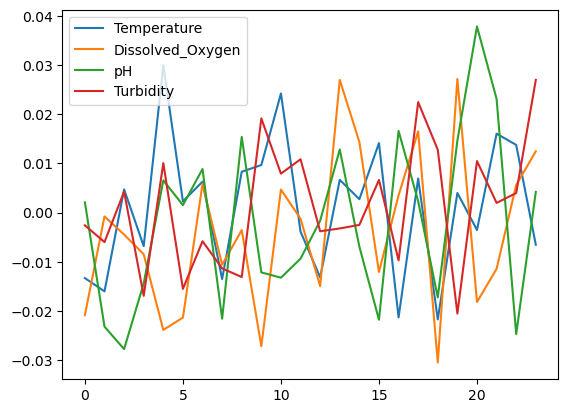

In [64]:
autocorr = {}
for i in water_quality.columns:
    autocorr[i] = []
    for j in range(1,24+1):
        autocorr[i].append(water_quality[i].autocorr(lag=j))
    plt.plot(range(0,24),autocorr[i],label=i)
    plt.legend()
    
plt.show()

In [88]:
maax = -10
dist = 10
for i in range(24):
   miin = np.min([autocorr[j][i] for j in water_quality.columns])
   temp_dist = np.sum([autocorr[j][i] for j in water_quality.columns])
   if(miin > maax):
       maax = miin
       print("\n",i)
       print([autocorr[j][i] for j in water_quality.columns])
   if(dist>temp_dist):
       dist = temp_dist
       print("\n DIST :",i)
       print([autocorr[j][i] for j in water_quality.columns])


 0
[-0.013326077199111322, -0.020858737643962653, 0.0020771909578610214, -0.0025944193901591946]

 DIST : 0
[-0.013326077199111322, -0.020858737643962653, 0.0020771909578610214, -0.0025944193901591946]

 DIST : 1
[-0.016022745938901697, -0.0007872133602466754, -0.023198495629351966, -0.005993393867162216]

 3
[-0.00682387663528867, -0.008473769136786852, -0.014409247247711431, -0.016921500502091957]

 DIST : 3
[-0.00682387663528867, -0.008473769136786852, -0.014409247247711431, -0.016921500502091957]

 6
[0.006300938926172103, 0.0058509650206771706, 0.008872385315509887, -0.0058245564816681505]

 DIST : 7
[-0.013521264295516545, -0.010608827735984972, -0.021584909206038838, -0.011351078643864965]

 13
[0.006668056363022106, 0.027004383659113708, 0.012843195425921316, -0.0032210246972413465]

 17
[0.00693768322097994, 0.01654097654882944, 0.0023055149879615227, 0.022481679883290875]


In [82]:
maax

0.0023055149879615227